In [119]:
from pathlib import Path
import os
import sys
import site, importlib, importlib.util

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    DRIVE = Path("/content/drive/MyDrive/NUIN")

    # Must not be named exactly "motionnet": once /content is on sys.path,
    # a bare directory called "motionnet" (no top-level __init__.py, since
    # this is a src/ layout) shadows the installed package as an implicit
    # PEP 420 namespace package -- import succeeds but __file__ is None.
    REPO = Path("/content/motionnet_cnn")
    if REPO.exists():
        !cd {REPO} && git pull
    else:
        !git clone https://github.com/guardomayas/motionnet.git {REPO}

    # --no-deps: Colab already ships numpy/scipy/matplotlib/h5py, but uv can't
    #   see them as satisfying the requirements and re-downloads the lot (~6 min).
    #   Deps are handled by the find_spec check below instead.
    # --no-build-isolation: skips re-downloading hatchling into a fresh build env,
    #   but then hatchling's build-time deps (editables) must already be present.
    # --python {sys.executable}: uv does its own interpreter discovery and can
    #   otherwise install into a different Python than the kernel is running.
    !pip install -q uv hatchling editables
    r = !cd {REPO} && uv pip install -e . --no-deps --no-build-isolation --python {sys.executable}
    if any("error" in l.lower() for l in r):
        print("\n".join(r))

    # An editable install drops a .pth, and .pth files only run at interpreter
    # startup -- this kernel booted before the install, so re-run site by hand.
    site.main()
    importlib.invalidate_caches()

    missing = [m for m in ("einops", "h5py", "scipy", "seaborn", "tqdm")
               if importlib.util.find_spec(m) is None]
    if missing:
        !pip install -q {" ".join(missing)}
        importlib.invalidate_caches()

    %cd /content

    DATA_PATH = Path("/content/vanhateren")
    if not DATA_PATH.exists():
        DATA_PATH.mkdir(parents=True)
        !cp "{DRIVE}/van_hateren/"*.iml {DATA_PATH}/

    CKPT_DIR = DRIVE / "motionnet_runs"
else:
    DATA_PATH = Path("~/NUIN/van_hateren/vanhateren_iml").expanduser()
    CKPT_DIR = Path("runs")

CKPT_DIR.mkdir(parents=True, exist_ok=True)
print(DATA_PATH, len(list(DATA_PATH.glob("*.iml"))), "images")

/content
/content/vanhateren 400 images


In [120]:
import motionnet
print(motionnet.__file__)   # should end in src/motionnet/__init__.py

/content/motionnet_cnn/src/motionnet/__init__.py


In [121]:
import numpy as np
import matplotlib.pyplot as plt
from motionnet.dataset import GetNaturalMovies, animate_sample, DiskCachedDataset
from torch.utils.data import DataLoader
from tqdm import tqdm
from IPython.display import HTML, display
from motionnet.dataset.van_hateren_utils import log_image
from pathlib import Path
import seaborn as sns
import motionnet
import torch.nn as nn
import torch.nn.functional as F
import torch
from torch.utils.data import Subset, DataLoader
import os
sns.set_context("talk")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
print(f"Using device: {device}")
print(os.getcwd())

Using device: cuda
/content


In [122]:
## GLOBAL VARS
CACHE_DIR = (DRIVE / "motionnet/cache") if IN_COLAB else Path("/home/guardomayas/NUIN/motionnet/data/coeffs")
N_IMAGES = 300
RNG      = np.random.default_rng(0)
# DPP      = 1/60 # Van Hateren images are 1/60 deg per pixel 
plot_vid = True


In [123]:
from motionnet.dataset import build_coeff_cache, split_images

CFG = dict(eye_size=28, spacing_px = None, blur_px=13, start_jitter=100, 
           contrast_range=(0.5, 1.0), noise_std=0.1,
           frames_per_segment=75*2, fps=75,
           vel_std_deg_s=(120, 70), samples_per_image=6)

RHO_PHI = 1.08                                   # matches the class default
SIGMA_PX = CFG["blur_px"] * RHO_PHI / 2.3548

train_files, val_files = split_images(DATA_PATH, n_images=N_IMAGES, 
                                      val_frac=0.2, stride=1)

CACHE_DIR.mkdir(parents=True, exist_ok=True)
train_cache = CACHE_DIR / f"train_n{len(train_files)}_blur{CFG['blur_px']}.npy"
val_cache   = CACHE_DIR / f"val_n{len(val_files)}_blur{CFG['blur_px']}.npy"

if not train_cache.exists():
    build_coeff_cache(train_files, train_cache, SIGMA_PX)
if not val_cache.exists():
    build_coeff_cache(val_files, val_cache, SIGMA_PX)

train_ds = DiskCachedDataset(GetNaturalMovies(files=train_files, coeff_cache=train_cache,
                            seed=1, **CFG), cache_dir=CACHE_DIR/"movies_train")
val_ds   = DiskCachedDataset(GetNaturalMovies(files=val_files, coeff_cache=val_cache,
                            seed=99, **CFG), cache_dir=CACHE_DIR/"movies_val")

print("Training data: ", len(train_ds))
print("Validation data: ", len(val_ds))

  0/240
  50/240
  100/240
  150/240
  200/240
  0/60
  50/60


/tmp/ipykernel_4553/3408522706.py:23: RuntimeWarning: excursion budget is tight on x: limit 475 px is 1.6 sigma of the position spread (293 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 150), or start_jitter (now 100).
  train_ds = DiskCachedDataset(GetNaturalMovies(files=train_files, coeff_cache=train_cache,
/tmp/ipykernel_4553/3408522706.py:23: RuntimeWarning: excursion budget is tight on y: limit 219 px is 1.3 sigma of the position spread (171 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 150), or start_jitter (now 100).
  train_ds = DiskCachedDataset(GetNaturalMovies(files=train_files, coeff_cache=train_cache,


Training data:  1440
Validation data:  360


/tmp/ipykernel_4553/3408522706.py:25: RuntimeWarning: excursion budget is tight on x: limit 475 px is 1.6 sigma of the position spread (293 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 150), or start_jitter (now 100).
  val_ds   = DiskCachedDataset(GetNaturalMovies(files=val_files, coeff_cache=val_cache,
/tmp/ipykernel_4553/3408522706.py:25: RuntimeWarning: excursion budget is tight on y: limit 219 px is 1.3 sigma of the position spread (171 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 150), or start_jitter (now 100).
  val_ds   = DiskCachedDataset(GetNaturalMovies(files=val_files, coeff_cache=val_cache,


In [ ]:
from IPython.display import HTML, display
anim = animate_sample(train_ds, idx=0, stride=3)
display(HTML(anim.to_jshtml()))
#     # plt.close(anim._fig)          # suppress the static figure

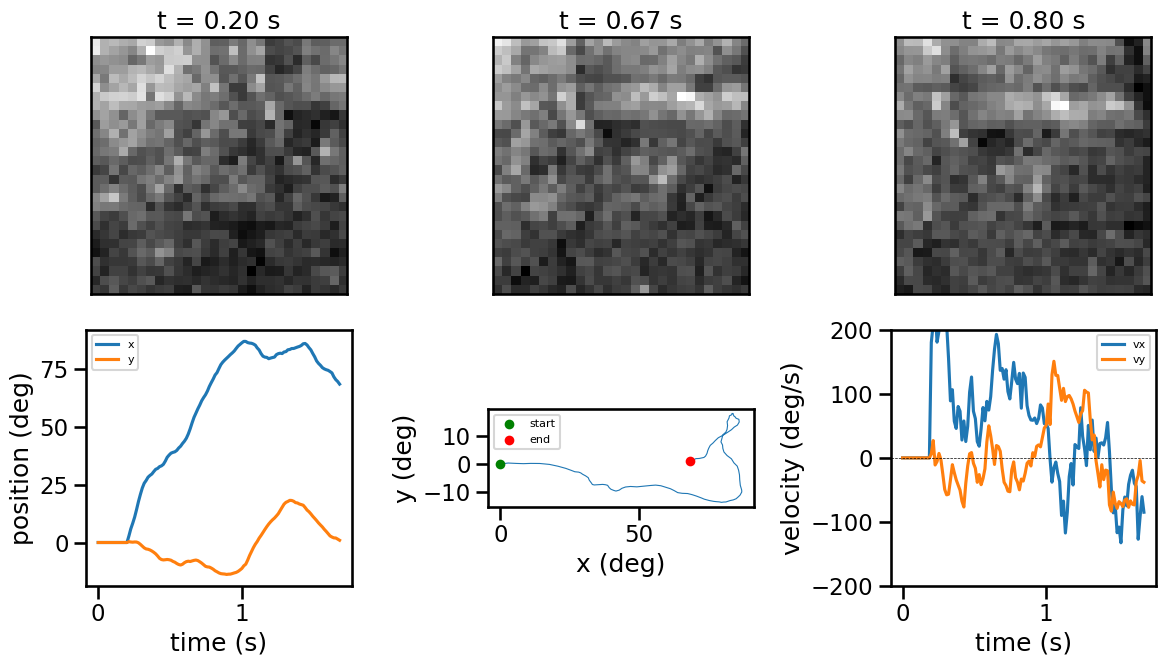

In [ ]:
d = train_ds
s = d[0]
movie = s["movie"].numpy()
vel   = s["vel_deg_s"].numpy()
pos   = s["pos_px"].numpy() * d.dpp        # source px -> deg
t_s   = np.arange(len(vel)) / d.fps
frames = [15, 50, 60]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for i, f in enumerate(frames):
    axes[0, i].imshow(movie[f, 0], cmap="gray", interpolation="nearest")
    axes[0, i].set_title(f"t = {f / d.fps:.2f} s")
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])

axes[1, 0].plot(t_s, pos[:, 0], label="x")
axes[1, 0].plot(t_s, pos[:, 1], label="y")
axes[1, 0].set(xlabel="time (s)", ylabel="position (deg)")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(pos[:, 0], pos[:, 1], lw=0.8)
axes[1, 1].scatter(*pos[0], c="g", s=30, zorder=3, label="start")
axes[1, 1].scatter(*pos[-1], c="r", s=30, zorder=3, label="end")
axes[1, 1].set(xlabel="x (deg)", ylabel="y (deg)")
axes[1, 1].set_aspect("equal")
axes[1, 1].legend(fontsize=8)

axes[1, 2].plot(t_s, vel[:, 0], label="vx")
axes[1, 2].plot(t_s, vel[:, 1], label="vy")
axes[1, 2].axhline(0, ls='--', color="k", lw=0.5)
axes[1, 2].set(xlabel="time (s)", ylabel="velocity (deg/s)", ylim=(-200,200))
axes[1, 2].legend(fontsize=8)

fig.tight_layout()

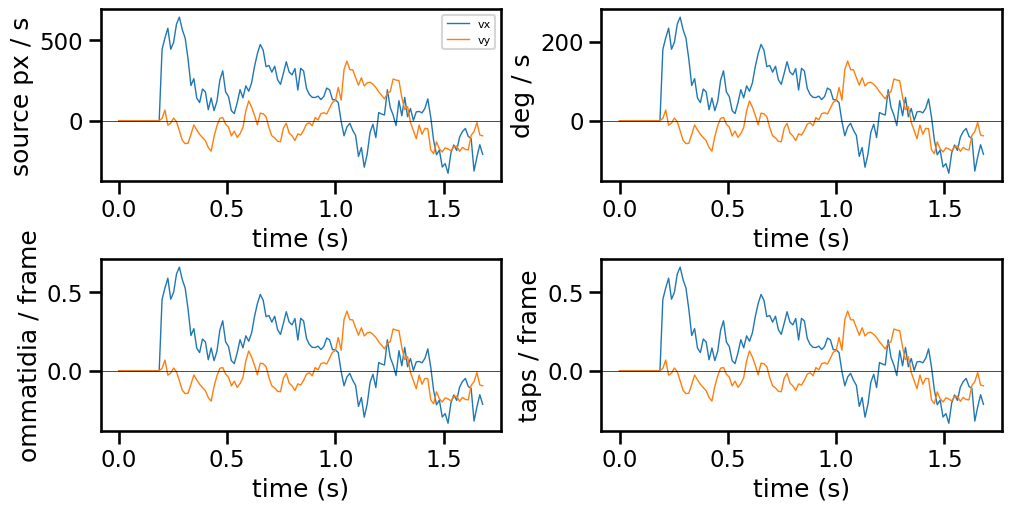

In [ ]:
#deg_s = tap_frame × spacing_px × fps × dpp.
vels = [
    (s["vel_px_s"].numpy(),      "source px / s"),
    (s["vel_deg_s"].numpy(),     "deg / s"),
    (s["vel_omm_frame"].numpy(), "ommatidia / frame"),
    (s["vel_tap_frame"].numpy(), "taps / frame"),
]
t_s = np.arange(len(vels[0][0])) / d.fps

fig, axes = plt.subplots(2, 2, figsize=(10, 5), layout="constrained")
for ax, (v, unit) in zip(axes.ravel(), vels):
    ax.plot(t_s, v[:, 0], label="vx", lw=1)
    ax.plot(t_s, v[:, 1], label="vy", lw=1)
    ax.axhline(0, color="k", lw=0.5)
    ax.set(xlabel="time (s)", ylabel=unit)
axes[0,0].legend(fontsize=8)

## Setting up a CNN

In [ ]:
print(movie.shape)

(127, 1, 28, 28)


In [ ]:
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=4,
                      pin_memory=True, drop_last=True, persistent_workers=True)
val_dl   = DataLoader(val_ds, batch_size=16, num_workers=2,
                      persistent_workers=True)

In [ ]:
from IPython.display import HTML, display
import torch.nn as nn
import torch.nn.functional as F
import torch

class CNN(nn.Module):
    def __init__(self,
                 num_neurons=8,
                 height=50,
                 width=50,
                 rf_size_1=5,
                 rf_size_2=7,
                 max_delay=70,
                 num_subunits_1=8,
                 num_subunits_2=8,
                 initial_bias=1.0,
                 mean_function=F.softplus,
                 input_noise_std=0.0,
                 activity_noise_std=0.0,
                 dropout_p=0.0):

        super().__init__()

        self.num_neurons = num_neurons
        self.height = height
        self.width = width
        self.max_delay = max_delay
        self.rf_size_1 = rf_size_1
        self.rf_size_2 = rf_size_2
        self.num_subunits_1 = num_subunits_1
        self.num_subunits_2 = num_subunits_2
        self.mean_function = mean_function

        # Noise / regularization
        self.input_noise_std = input_noise_std
        self.activity_noise_std = activity_noise_std
        self.dropout = nn.Dropout(p=dropout_p)

        self.spatial_conv = nn.Conv2d(
            in_channels=1,
            out_channels=num_subunits_1,
            kernel_size=rf_size_1,
            padding=0,
            bias=True,
        )

        H1 = height - rf_size_1 + 1
        W1 = width - rf_size_1 + 1
        self.H1 = H1
        self.W1 = W1

        self.temporal_conv = nn.Conv1d(
            in_channels=num_subunits_1,
            out_channels=num_subunits_1,
            kernel_size=max_delay,
            groups=num_subunits_1,
            bias=True,
        )

        self.layer2 = nn.Conv2d(
            in_channels=num_subunits_1,
            out_channels=num_subunits_2,
            kernel_size=rf_size_2,
            padding=0,
            bias=True,
        )

        H2 = H1 - rf_size_2 + 1
        W2 = W1 - rf_size_2 + 1
        self.H2 = H2
        self.W2 = W2

        self.layer3 = nn.Linear(num_subunits_2, num_neurons)

        bias = torch.log(torch.exp(torch.tensor(float(initial_bias))) - 1.0)
        nn.init.constant_(self.layer3.bias, bias)

    def add_input_noise(self, movie):
        if self.training and self.input_noise_std > 0:
            movie = movie + self.input_noise_std * torch.randn_like(movie)

            # Optional if your movie is normalized to [0, 1]
            # movie = movie.clamp(0.0, 1.0)

        return movie

    def add_activity_noise(self, x):
        if self.training and self.activity_noise_std > 0:
            # Multiplicative noise. Keeps noise scale proportional to activity.
            noise = self.activity_noise_std * torch.randn_like(x)
            x = x * (1.0 + noise)

            # Since activations after ReLU should remain nonnegative
            x = torch.clamp(x, min=0.0)

        return x

    def forward(self, movie):
        """
        movie: (B, T, 1, H, W)
        returns: rates, shape (B, T, num_neurons)
        """

        movie = self.add_input_noise(movie)

        B, T, C, H, W = movie.shape

        # -------------------------------------------------------
        # 1. Spatial conv per frame
        # -------------------------------------------------------
        x = movie.reshape(B * T, C, H, W)
        x = self.spatial_conv(x)

        _, N1, H1, W1 = x.shape

        x = x.reshape(B, T, N1, H1, W1)

        # -------------------------------------------------------
        # 2. Temporal conv at each spatial location
        # -------------------------------------------------------
        x = x.permute(0, 3, 4, 2, 1)              # (B, H1, W1, N1, T)
        x = x.reshape(B * H1 * W1, N1, T)         # (B*H1*W1, N1, T)

        # causal temporal padding
        x = F.pad(x, (self.max_delay - 1, 0))
        x = self.temporal_conv(x)

        x = x.reshape(B, H1, W1, N1, T)
        x = x.permute(0, 4, 3, 1, 2)              # (B, T, N1, H1, W1)

        x = F.relu(x)
        x = self.add_activity_noise(x)

        # -------------------------------------------------------
        # 3. Second spatial conv
        # -------------------------------------------------------
        x = x.reshape(B * T, N1, H1, W1)
        x = self.layer2(x)
        x = F.relu(x)
        x = self.add_activity_noise(x)

        _, N2, H2, W2 = x.shape

        # -------------------------------------------------------
        # 4. Pooling over space + linear readout
        # -------------------------------------------------------
        x_pool = x.mean(dim=(-1, -2))              # (B*T, N2)

        # Optional dropout after pooling
        x_pool = self.dropout(x_pool)

        drive = self.layer3(x_pool)
        rates = self.mean_function(drive)

        rates = rates.reshape(B, T, self.num_neurons)

        return rates + 1e-8
    
class LinearVelocityDecoder(nn.Module):
    def __init__(self, num_neurons, out_dim=2):
        super().__init__()
        self.decoder = nn.Linear(num_neurons, out_dim)

        nn.init.normal_(self.decoder.weight, mean=0.0, std=0.1)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, rates):
        return self.decoder(rates)
    
    
class RetinaVelocityModel(nn.Module):
    def __init__(self, retina, num_neurons):
        super().__init__()
        self.retina = retina
        self.decoder = LinearVelocityDecoder(num_neurons=num_neurons, out_dim=2)

    def forward(self, movie, return_rates=False):
        rates = self.retina(movie)          # (B, T, N), nonnegative
        pred_vel = self.decoder(rates)      # (B, T, 2), signed

        if return_rates:
            return rates, pred_vel

        return pred_vel

In [ ]:
output_neurons = 8

retina = CNN(
    num_neurons=output_neurons,
    height=50,
    width=50,
    rf_size_1=9,
    rf_size_2=11,
    max_delay=15,
    num_subunits_1=5,
    num_subunits_2=6,
    initial_bias=1,
    mean_function=F.softplus,

    # noise / regularization
    input_noise_std=0.0,
    activity_noise_std=0.0,
    dropout_p=0.0,
)
model = RetinaVelocityModel(
    retina=retina,
    num_neurons=output_neurons,
).to(device)

In [ ]:
### Over fit a small dataset
loss_fn = nn.MSELoss()
batch = next(iter(train_dl))

movie = batch["movie"].to(device)
target = batch["vel_tap_frame"].to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)

for step in range(1000):
    pred = model(movie)
    valid = slice(train_ds.gray_frames, None)
    loss = loss_fn(pred[:, valid], target[:, valid])
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % 100 == 0:
        print(step, loss.item())

0 0.05981574207544327
100 0.04326016455888748
200 0.030701475217938423
300 0.025098618119955063
400 0.021872712299227715
500 0.019561653956770897
600 0.017894988879561424
700 0.016582107171416283
800 0.015490956604480743
900 0.014709612354636192


/content/motionnet_cnn/src/motionnet/dataset/utils.py:93: RuntimeWarning: acceptance rate 80% over 51 samples (64 draws): traces are leaving the scene bounds often, so p(v) is truncated well inside its tails and sampling is 1.3x slower than needed. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 112), or start_jitter (now 100).
  sample = self.base_ds[idx]
/content/motionnet_cnn/src/motionnet/dataset/utils.py:93: RuntimeWarning: acceptance rate 71% over 50 samples (70 draws): traces are leaving the scene bounds often, so p(v) is truncated well inside its tails and sampling is 1.4x slower than needed. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 112), or start_jitter (now 100).
  sample = self.base_ds[idx]
/content/motionnet_cnn/src/motionnet/dataset/utils.py:93: RuntimeWarning: acceptance rate 79% over 167 samples (212 draws): traces are leaving the scene bounds often, so p(v) is truncated well inside its tails and sampling is 1.3x slower than nee

In [ ]:
t = target[:, valid]
print("target var:", t.var().item())                    # predict-mean baseline
print("R²:", 1 - loss.item() / t.var().item())
print("pred std:", pred[:, valid].std().item(), "target std:", t.std().item())
err = (pred[:, valid] - target[:, valid]).pow(2).mean((0, 1))
print(1 - err / target[:, valid].var((0, 1)))

target var: 0.059372611343860626
R²: 0.7632245910549029
pred std: 0.21132083237171173 target std: 0.24366495013237
tensor([0.8128, 0.5697], device='cuda:0', grad_fn=<RsubBackward1>)


In [ ]:
print("train batches per epoch:", len(train_dl))
print("val batches per epoch:", len(val_dl))
print("train samples:", len(train_dl.dataset))
print("val samples:", len(val_dl.dataset))

train batches per epoch: 90
val batches per epoch: 23
train samples: 1440
val samples: 360


## full training loop


In [ ]:
import torch
import torch.nn.functional as F

_LAPLACIAN = torch.tensor([[0., 1., 0.],
                           [1., -4., 1.],
                           [0., 1., 0.]]).view(1, 1, 3, 3)


def laplacian_penalty(weight):
    """Mean squared spatial Laplacian of a conv kernel.

    weight: (out, in, k, k). Penalises high spatial frequency in the filter
    itself -- frequencies the optics already removed from the input, so they
    carry no signal and are otherwise unconstrained.
    """
    w = weight.flatten(0, 1).unsqueeze(1)                 # (out*in, 1, k, k)
    lap = _LAPLACIAN.to(weight.device, weight.dtype)
    return F.conv2d(w, lap).pow(2).mean()

In [ ]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
### BEST PERFORMING MODEL SO FAR (6 neurons, RFs: 9 and 11, 
#                               subunits 5 and 6, 15 delay)
# dropout 0.02, input noise 0.005, activity noise 0.02, initial bias 1.0
output_neurons = 4
LAMBDA = 1e-2

retina = CNN(
    num_neurons=output_neurons,
    height=50,
    width=50,
    rf_size_1=9,
    rf_size_2=7,
    max_delay=15,
    num_subunits_1= 5,
    num_subunits_2=6,
    initial_bias=1.0,
    mean_function=F.softplus,

    # noise / regularization
    input_noise_std=0.01,
    activity_noise_std=0.00,
    dropout_p=0.00,
)

model = RetinaVelocityModel(
    retina=retina,
    num_neurons=output_neurons,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

history = {
    "train_loss": [],
    "val_loss": [],
}


def run_epoch_direct(
    model,
    loader,
    optimizer=None,
    device="cpu",
    desc="",
):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_n = 0

    pbar = tqdm(loader, desc=desc, leave=False)

    for batch in pbar:
        movie = batch["movie"].to(device)
        target = batch["vel_tap_frame"].to(device)

        pred = model(movie)

        valid = slice(train_ds.gray_frames, None)
        loss = loss_fn(pred[:, valid], target[:, valid])
        smooth = laplacian_penalty(model.retina.spatial_conv.weight)
        loss_sm = loss + LAMBDA * smooth

        if is_train:
            optimizer.zero_grad()
            loss_sm.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        B = movie.shape[0]
        total_loss += loss_sm.item() * B
        total_n += B

        # pbar.set_postfix({"vel": total_loss / total_n})

    return total_loss / total_n


num_epochs = 150

for epoch in range(1, num_epochs + 1):
    train_loss = run_epoch_direct(
        model,
        train_dl,
        optimizer=optimizer,
        device=device,
        desc=f"Tiny instant epoch {epoch:03d} train",
    )

    with torch.no_grad():
        val_loss = run_epoch_direct(
            model,
            val_dl,
            optimizer=None,
            device=device,
            desc=f"Tiny instant epoch {epoch:03d} val",
        )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    if epoch == 1 or epoch % 10 == 0 or epoch == num_epochs:
        print(f"Epoch {epoch:03d} | train {train_loss:.4f} | val {val_loss:.4f}")

Tiny instant epoch 001 train:   0%|          | 0/90 [00:00<?, ?it/s]

Tiny instant epoch 001 val:   0%|          | 0/23 [00:00<?, ?it/s]

/content/motionnet_cnn/src/motionnet/dataset/utils.py:93: RuntimeWarning: acceptance rate 76% over 50 samples (66 draws): traces are leaving the scene bounds often, so p(v) is truncated well inside its tails and sampling is 1.3x slower than needed. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 112), or start_jitter (now 100).
  sample = self.base_ds[idx]
/content/motionnet_cnn/src/motionnet/dataset/utils.py:93: RuntimeWarning: acceptance rate 80% over 63 samples (79 draws): traces are leaving the scene bounds often, so p(v) is truncated well inside its tails and sampling is 1.3x slower than needed. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 112), or start_jitter (now 100).
  sample = self.base_ds[idx]


Epoch 001 | train 0.0614 | val 0.0552


Tiny instant epoch 002 train:   0%|          | 0/90 [00:00<?, ?it/s]

...

Tiny instant epoch 149 train:   0%|          | 0/90 [00:00<?, ?it/s]

Tiny instant epoch 149 val:   0%|          | 0/23 [00:00<?, ?it/s]

Tiny instant epoch 150 train:   0%|          | 0/90 [00:00<?, ?it/s]

Tiny instant epoch 150 val:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 150 | train 0.0149 | val 0.0168


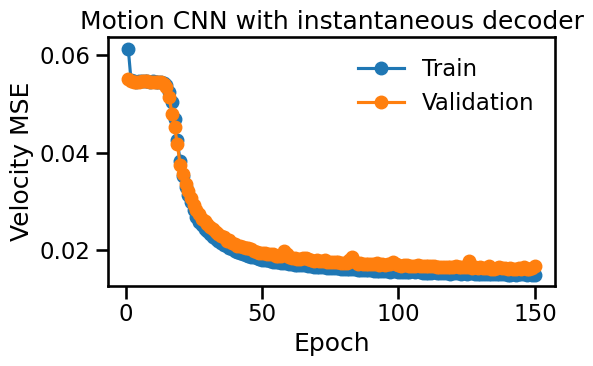

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="Train")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation")
# plt.axhline(1.0, linestyle="--", linewidth=1, label="Zero baseline ≈ 1")
plt.xlabel("Epoch")
plt.ylabel("Velocity MSE")
plt.title("Motion CNN with instantaneous decoder")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def compute_val_r2_per_movie(
    model,
    val_loader,
    device,
):
    model.eval()

    r2_per_seq = []
    pred_all = []
    target_all = []

    for batch in val_loader:
        movie = batch["movie"].to(device)
        target = batch["vel_tap_frame"].to(device)  # raw px/s, (B, T, 2)
        valid = slice(train_ds.gray_frames, None)
        pred = model(movie)                   # normalized, (B, T, 2)
        pred = pred[:, valid]
        target = target[:, valid]

        # Per movie R² over both vx and vy together
        ss_res = ((target - pred) ** 2).sum(dim=(1, 2))
        target_mean = target.mean(dim=(1, 2), keepdim=True)
        ss_tot = ((target - target_mean) ** 2).sum(dim=(1, 2))

        r2 = 1.0 - ss_res / (ss_tot + 1e-8)

        r2_per_seq.extend(r2.detach().cpu().numpy())
        pred_all.append(pred.detach().cpu())
        target_all.append(target.detach().cpu())

    r2_per_seq = np.asarray(r2_per_seq)
    pred_all = torch.cat(pred_all, dim=0)        # (Nval, T-gray, 2)
    target_all = torch.cat(target_all, dim=0)

    return r2_per_seq, pred_all, target_all

r2_per_seq, pred_val, target_val = compute_val_r2_per_movie(
    model=model,
    val_loader= val_dl,
    device=device,
)

mean_r2 = np.mean(r2_per_seq)
sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

print("Mean R²:", mean_r2)
print("SEM R²:", sem_r2)
print("N validation movies:", len(r2_per_seq))
print("Min/Max R²:", r2_per_seq.min(), r2_per_seq.max())

Mean R²: 0.6235079
SEM R²: 0.013384742291008169
N validation movies: 360
Min/Max R²: -0.47781074 0.9316305


/tmp/ipykernel_4553/3064212615.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


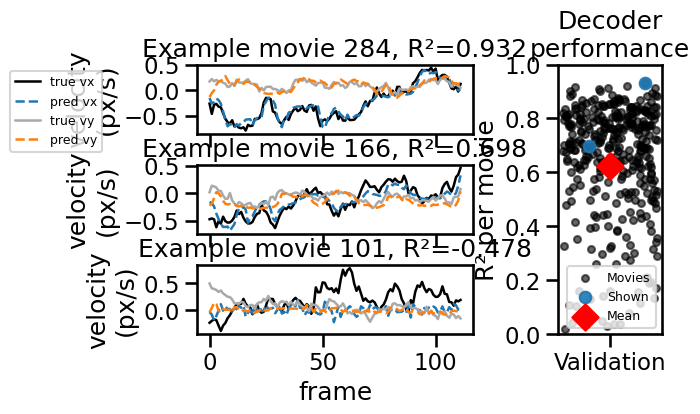

In [ ]:
from matplotlib.gridspec import GridSpec


def plot_validation_summary_two_columns(
    r2_per_seq,
    pred_val,
    target_val,
    n_examples=3,
    example_mode="best",  # "best", "worst", or "mixed"
    figsize=(11, 7),
):
    # Convert tensors to numpy if needed
    if hasattr(pred_val, "detach"):
        pred_val_np = pred_val.detach().cpu().numpy()
    else:
        pred_val_np = np.asarray(pred_val)

    if hasattr(target_val, "detach"):
        target_val_np = target_val.detach().cpu().numpy()
    else:
        target_val_np = np.asarray(target_val)

    r2_per_seq = np.asarray(r2_per_seq)

    # Choose example indices
    order = np.argsort(r2_per_seq)

    if example_mode == "best":
        example_idxs = order[-n_examples:][::-1]
    elif example_mode == "worst":
        example_idxs = order[:n_examples]
    elif example_mode == "mixed":
        example_idxs = np.array([
            order[-1],
            order[len(order) // 2],
            order[0],
        ])
        example_idxs = example_idxs[:n_examples]
    else:
        raise ValueError("example_mode must be 'best', 'worst', or 'mixed'.")

    mean_r2 = np.mean(r2_per_seq)
    sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

    # Figure layout
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        nrows=len(example_idxs),
        ncols=2,
        width_ratios=[3.2, 1.2],
        wspace=0.45,
        hspace=0.45,
        figure=fig,
    )

    # -----------------------------
    # Left column: example traces
    # -----------------------------
    for row, idx in enumerate(example_idxs):
        ax = fig.add_subplot(gs[row, 0])

        pred = pred_val_np[idx]
        target = target_val_np[idx]

        t = np.arange(target.shape[0])

        ax.plot(t, target[:, 0], label="true vx", linewidth=1.8, c='k')
        ax.plot(t, pred[:, 0], label="pred vx", linewidth=1.8, linestyle="--")

        ax.plot(t, target[:, 1], label="true vy", linewidth=1.8, c='darkgray')
        ax.plot(t, pred[:, 1], label="pred vy", linewidth=1.8, linestyle="--")

        ax.set_title(f"Movie {idx}, R²={r2_per_seq[idx]:.3f}")
        ax.set_ylabel("velocity\n(px/s)")

        if row == len(example_idxs) - 1:
            ax.set_xlabel("frame")
        else:
            ax.set_xticklabels([])

        if row == 0:
            ax.legend(ncol=1, fontsize=9, loc="upper left",
                      bbox_to_anchor=(-.7, 1.0),)

    # -----------------------------
    # Right column: R² scatter plot
    # -----------------------------
    ax_r2 = fig.add_subplot(gs[:, 1])

    x0 = 0
    rng = np.random.default_rng(0)
    x_jitter = x0 + rng.uniform(-0.15, 0.15, size=len(r2_per_seq))

    ax_r2.scatter(
        x_jitter,
        r2_per_seq,
        alpha=0.6,
        s=25,
        c="k",
        label="Movies",
    )

    # Highlight selected examples
    ax_r2.scatter(
        x_jitter[example_idxs],
        r2_per_seq[example_idxs],
        alpha=0.9,
        s=70,
        c="tab:blue",
        label="Shown",
    )

    # Mean marker + SEM
    ax_r2.scatter(
        x0,
        mean_r2,
        s=180,
        marker="D",
        c="red",
        label="Mean",
        zorder=5,
    )

    ax_r2.errorbar(
        x0,
        mean_r2,
        yerr=sem_r2,
        fmt="none",
        ecolor="red",
        capsize=5,
        linewidth=2,
        zorder=4,
    )

    ax_r2.axhline(0, linestyle="--", linewidth=1)
    ax_r2.set_xticks([x0])
    ax_r2.set_xticklabels(["Validation"])
    ax_r2.set_ylim(0, 1)
    ax_r2.set_ylabel("R² per movie")
    ax_r2.set_title("Decoder\nperformance")
    ax_r2.legend(fontsize=9, loc="lower right")

    # fig.suptitle("Validation performance summary", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    return fig

fig = plot_validation_summary_two_columns(
    r2_per_seq=r2_per_seq,
    pred_val=pred_val,
    target_val=target_val,
    n_examples=3,
    example_mode="mixed",
    figsize=(6, 3.5),
)

In [ ]:
def plot_cnn_subunits_1(cnn, fps=75.0, deg_per_tap=None):
    """First-layer separable subunits: temporal kernel + spatial RF.

    deg_per_tap: dataset.deg_per_tap. If given, the spatial axis is in
    degrees of visual angle; otherwise in taps.
    """
    n_su = cnn.num_subunits_1
    max_delay = cnn.max_delay

    # .clone() is load-bearing: .detach() shares storage with the parameter,
    # so the in-place normalisation below would edit the trained model.
    tw = cnn.temporal_conv.weight[:, 0].detach().cpu().clone()   # (N1, max_delay)
    sw = cnn.spatial_conv.weight[:, 0].detach().cpu().clone()    # (N1, k, k)

    # Sign and gain trade off freely between the two factors; fix the sign by
    # the dominant lobe and push the gain into the temporal kernel.
    for n in range(n_su):
        if sw[n].min().abs() > sw[n].max():
            sw[n], tw[n] = -sw[n], -tw[n]
        scale = torch.linalg.norm(sw[n])
        sw[n] /= scale
        tw[n] *= scale

    vlim, ylim = sw.abs().max(), tw.abs().max()
    t_ms = torch.arange(-max_delay + 1, 1) * (1000.0 / fps)

    k = sw.shape[-1]
    if deg_per_tap is None:
        half, unit = k / 2, "taps"
    else:
        half, unit = k * deg_per_tap / 2, "deg"
    extent = [-half, half, -half, half]

    fig, axs = plt.subplots(n_su, 3, figsize=(8, 3.2 * n_su), squeeze=False,
                            gridspec_kw=dict(width_ratios=[1, 1.9, 0.1]))

    for n in range(n_su):
        axs[n, 0].plot(t_ms, tw[n])
        axs[n, 0].axhline(0, ls=":", c="k", lw=0.8)
        axs[n, 0].set_ylim(-ylim, ylim)
        if n == n_su - 1:
            axs[n, 0].set_xlabel(r"$\Delta t$ [ms]")
        else:
            axs[n, 0].tick_params(labelbottom=False)

        im = axs[n, 1].imshow(sw[n], vmin=-vlim, vmax=vlim, cmap="RdBu_r",
                              extent=extent, interpolation="nearest")
        axs[n, 1].set_title(f"subunit 1,{n + 1}  ({k * (deg_per_tap or 1):.1f} {unit})")
        if n == n_su - 1:
            axs[n, 1].set_xlabel("azimuth [deg]" if deg_per_tap else "taps")
        plt.colorbar(im, cax=axs[n, 2])

    fig.tight_layout()
    return fig, axs

def plot_cnn_subunits2(cnn: nn.Module):
    """
    Plot the second layer of subunits of a CNN.
    """
    cnn_filters_2 = cnn.layer2.weight.to("cpu").detach()

    fig, axs = plt.subplots(cnn.num_subunits_2,
                            cnn.num_subunits_1,
                            figsize=(4 * cnn.num_subunits_2,
                                    4 * cnn.num_subunits_1),
                            sharex=True, sharey=True)
    # vlim = abs(cnn_filters_2).max()
    percentile = 99
    vlim = torch.quantile(cnn_filters_2.abs().flatten(), percentile / 100).item()
    for i in range(cnn.num_subunits_2):
        for j in range(cnn.num_subunits_1):
            axs[i, j].imshow(cnn_filters_2[i, j],
                            vmin=-vlim, vmax=vlim, cmap="RdBu_r")

            axs[i, j].set_title('subunit 1,{} $\\to$ 2,{}'.format(j+1,i+1))


(<Figure size 800x1280 with 12 Axes>,
 array([[<Axes: >, <Axes: title={'center': 'subunit 1,1  (26.5 deg)'}>,
         <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,2  (26.5 deg)'}>,
         <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,3  (26.5 deg)'}>,
         <Axes: >],
        [<Axes: xlabel='$\\Delta t$ [ms]'>,
         <Axes: title={'center': 'subunit 1,4  (26.5 deg)'}, xlabel='azimuth [deg]'>,
         <Axes: >]], dtype=object))

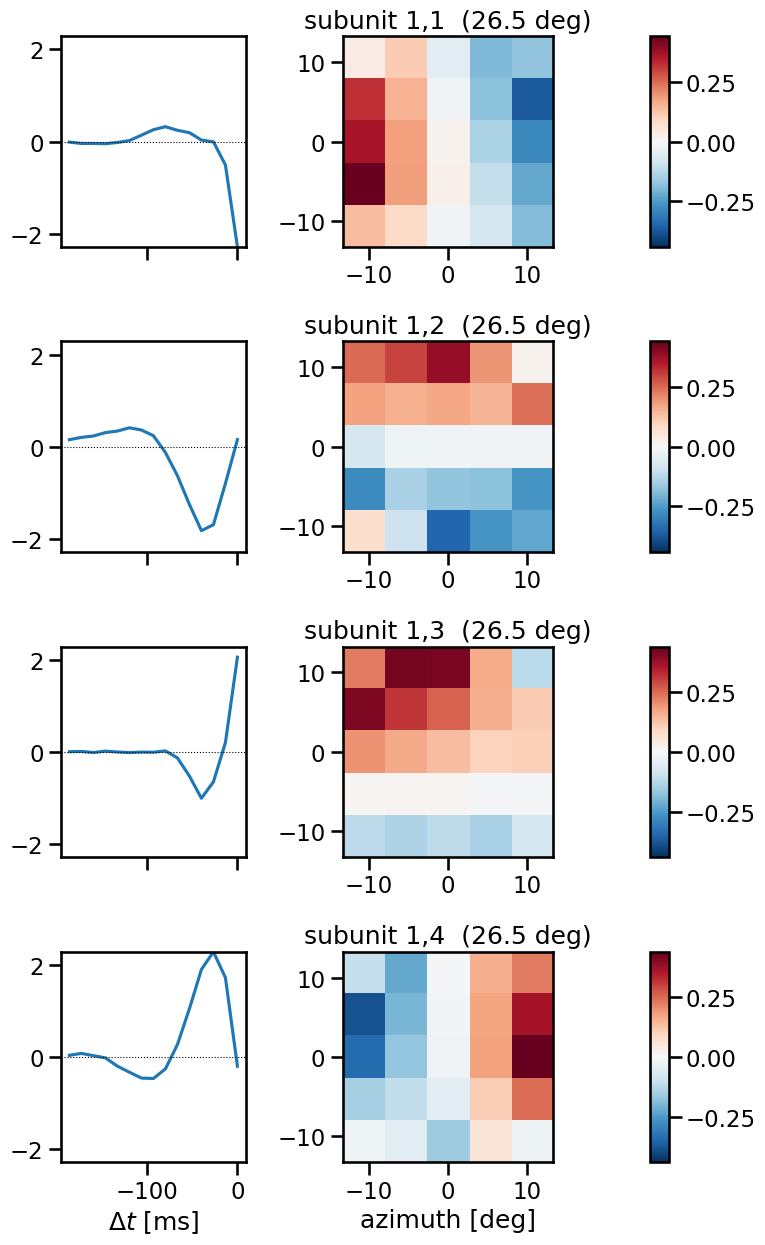

In [ ]:
plot_cnn_subunits_1(model.retina, fps=train_ds.fps, deg_per_tap=train_ds.deg_per_tap)

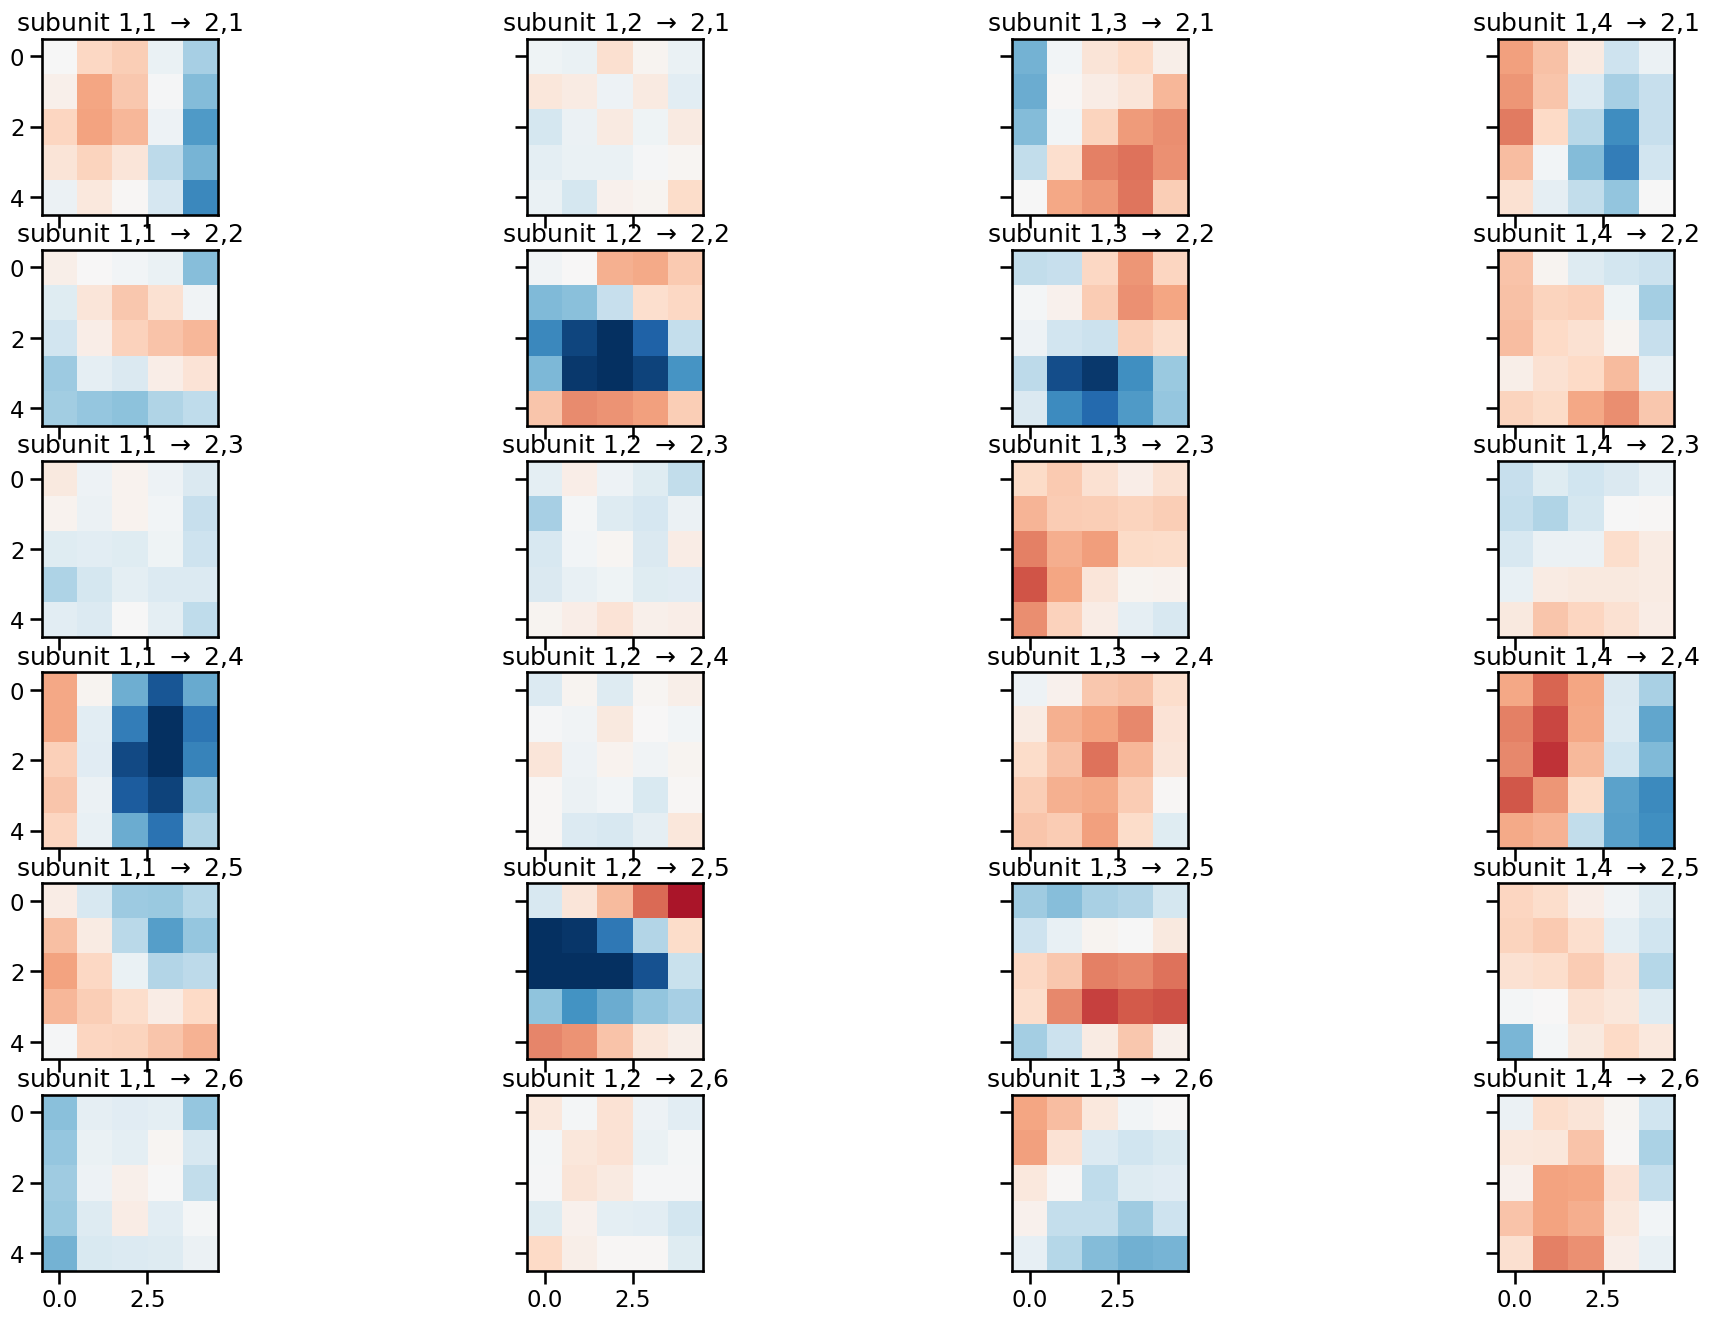

In [ ]:
plot_cnn_subunits2(retina)

(<Figure size 800x1280 with 12 Axes>,
 array([[<Axes: >, <Axes: title={'center': 'subunit 1,1'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,2'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,3'}>, <Axes: >],
        [<Axes: xlabel='$\\Delta t$ [ms]'>,
         <Axes: title={'center': 'subunit 1,4'}, xlabel='azimuth [deg]'>,
         <Axes: >]], dtype=object))

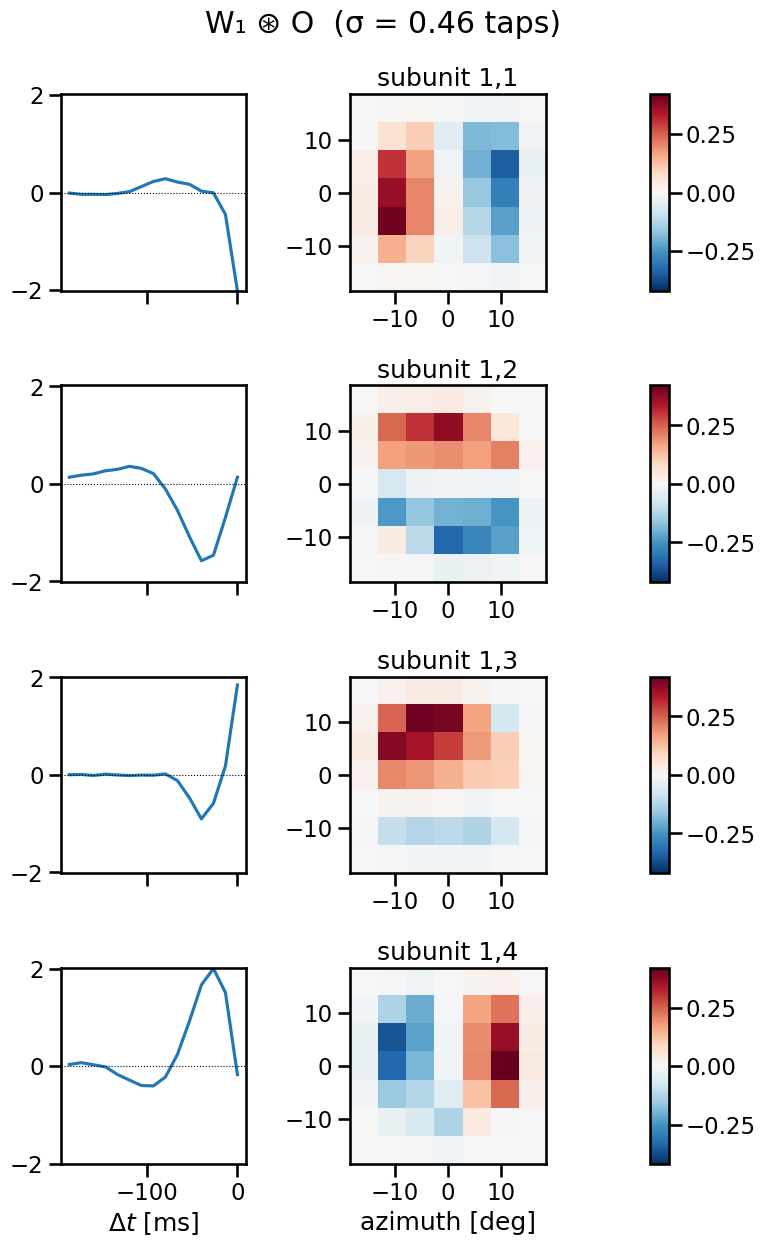

In [ ]:
import numpy as np
from scipy.signal import convolve2d


def acceptance_kernel(sigma_taps, truncate=3.0):
    """Ommatidial acceptance function sampled on the tap lattice."""
    r = max(1, int(round(truncate * sigma_taps)))
    ax = np.arange(-r, r + 1)
    g = np.exp(-ax ** 2 / (2 * sigma_taps ** 2))
    k = np.outer(g, g)
    return k / k.sum()


def effective_rf(cnn, dataset, truncate=3.0):
    """W1 convolved with the optics: the object comparable to a measured RF.

    The blur acted upstream of the network, so the learned weights carry no
    optics. Reverse-correlating the model against the *pre-blur* stimulus
    would recover this; convolving is exact because that path is linear.
    """
    sw = cnn.spatial_conv.weight[:, 0].detach().cpu().clone().numpy()
    sigma_taps = dataset.sigma_px / dataset.spacing_px
    k = acceptance_kernel(sigma_taps, truncate)
    eff = np.stack([convolve2d(w, k, mode="full") for w in sw])
    return eff, sigma_taps

def plot_cnn_subunits_1(cnn, dataset, effective=True, truncate=3.0):
    n_su, max_delay = cnn.num_subunits_1, cnn.max_delay
    tw = cnn.temporal_conv.weight[:, 0].detach().cpu().clone().numpy()

    if effective:
        sw, sigma_taps = effective_rf(cnn, dataset, truncate)
        label = f"W₁ ⊛ O  (σ = {sigma_taps:.2f} taps)"
    else:
        sw = cnn.spatial_conv.weight[:, 0].detach().cpu().clone().numpy()
        label = "W₁ (weights only)"

    for n in range(n_su):                       # fix sign, push gain to time
        if abs(sw[n].min()) > sw[n].max():
            sw[n], tw[n] = -sw[n], -tw[n]
        s = np.linalg.norm(sw[n])
        sw[n] /= s
        tw[n] *= s

    k = sw.shape[-1]
    half = k * dataset.deg_per_tap / 2
    extent = [-half, half, -half, half]
    t_ms = np.arange(-max_delay + 1, 1) * (1000.0 / dataset.fps)
    vlim, ylim = np.abs(sw).max(), np.abs(tw).max()

    fig, axs = plt.subplots(n_su, 3, figsize=(8, 3.2 * n_su), squeeze=False,
                            gridspec_kw=dict(width_ratios=[1, 1.9, 0.1]))
    for n in range(n_su):
        axs[n, 0].plot(t_ms, tw[n])
        axs[n, 0].axhline(0, ls=":", c="k", lw=0.8)
        axs[n, 0].set_ylim(-ylim, ylim)
        axs[n, 0].tick_params(labelbottom=(n == n_su - 1))
        im = axs[n, 1].imshow(sw[n], vmin=-vlim, vmax=vlim, cmap="RdBu_r",
                              extent=extent, interpolation="nearest")
        axs[n, 1].set_title(f"subunit 1,{n+1}")
        plt.colorbar(im, cax=axs[n, 2])
    axs[-1, 0].set_xlabel(r"$\Delta t$ [ms]")
    axs[-1, 1].set_xlabel("azimuth [deg]")
    fig.suptitle(label)
    fig.tight_layout()
    return fig, axs

plot_cnn_subunits_1(model.retina, train_ds)

(<Figure size 800x1280 with 12 Axes>,
 array([[<Axes: >, <Axes: title={'center': 'subunit 1,1'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,2'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,3'}>, <Axes: >],
        [<Axes: xlabel='$\\Delta t$ [ms]'>,
         <Axes: title={'center': 'subunit 1,4'}, xlabel='azimuth [deg]'>,
         <Axes: >]], dtype=object))

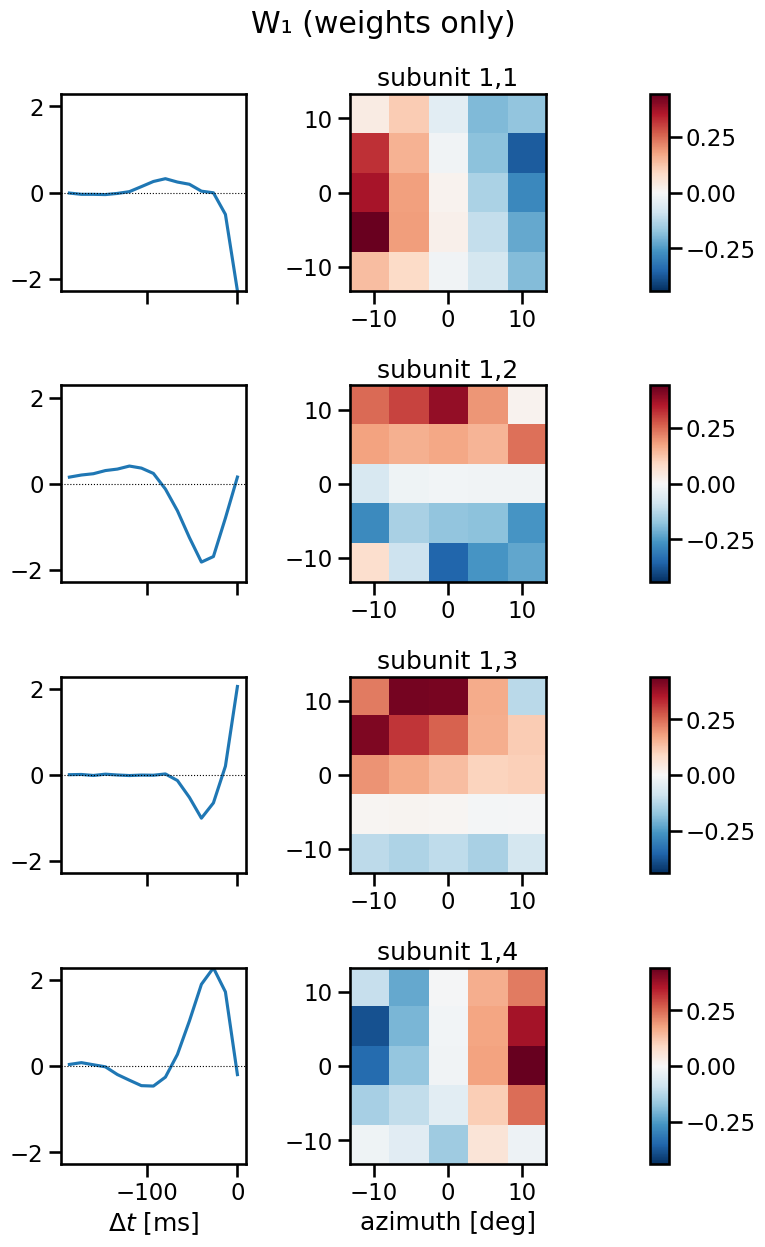

In [ ]:
plot_cnn_subunits_1(model.retina, train_ds, effective=False)   # raw W₁